# Activity 1 — Medical Insurance Cost Prediction

**Goal:** Predict a person's medical insurance cost (`charges`) from `age`, `sex`, `bmi`, `children`, `smoker` and `region` using **Linear Regression**.

**File required:** `insurance.csv` (keep it in the same folder as this notebook)

### How it works
- `pandas` loads and explores the data.
- Categorical columns (`smoker`, `region`) are encoded into numbers.
- `StandardScaler` puts numerical features on the same scale.
- `LinearRegression` learns one weight per feature.
- RMSE and R² tell us how good the predictions are.

## Setup — imports and loading the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,22,female,30.926,3,no,northwest,14687.46
1,54,male,17.885,2,no,southeast,18265.13
2,48,female,34.347,1,no,northwest,29390.49
3,38,male,35.199,0,no,southwest,5841.57
4,38,male,29.068,2,no,northeast,14326.19


## Task 1 — Load and explore the dataset

Check the size, data types, missing values and basic statistics. Then look at how `charges` behaves.

In [2]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nStatistical summary:")
df.describe()

Shape: (1338, 7)

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,41.393124,30.377753,1.071001,25526.188064
std,13.534665,6.191163,1.189663,15482.521553
min,18.000000,15.900000,0.000000,1122.000000
25%,30.000000,26.311500,0.000000,15451.280000
50%,42.000000,30.622000,1.000000,21097.245000
75%,53.000000,34.460750,2.000000,27936.522500
max,64.000000,48.377000,5.000000,63770.000000


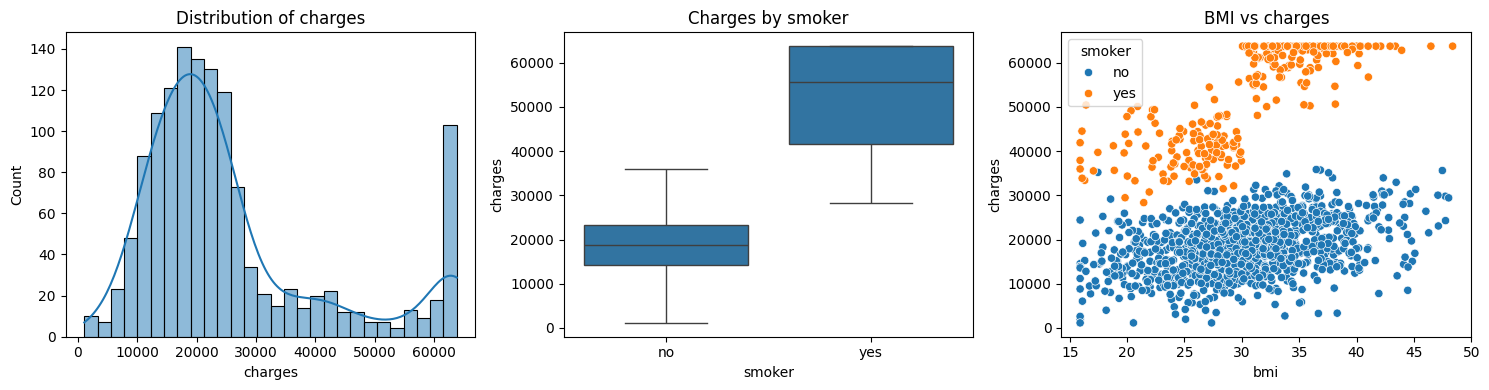

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["charges"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of charges")

sns.boxplot(x="smoker", y="charges", data=df, ax=axes[1])
axes[1].set_title("Charges by smoker")

sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df, ax=axes[2])
axes[2].set_title("BMI vs charges")

plt.tight_layout()
plt.show()

## Task 2 — Encode categorical features (`smoker`, `region`)

- `smoker` has two values (yes/no) → **label encoding** (yes = 1, no = 0).
- `region` has four unordered values → **one-hot encoding** (one binary column per region). Using label encoding here would wrongly suggest that one region is "bigger" than another.
- `sex` is also categorical (male/female), so it is encoded as well even though the lab only names the other two.

`drop_first=True` removes one redundant region column.

In [4]:
df_enc = df.copy()

df_enc["smoker"] = df_enc["smoker"].map({"yes": 1, "no": 0})
df_enc["sex"] = df_enc["sex"].map({"male": 1, "female": 0})
df_enc = pd.get_dummies(df_enc, columns=["region"], drop_first=True, dtype=int)

df_enc.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,22,0,30.926,3,0,14687.46,1,0,0
1,54,1,17.885,2,0,18265.13,0,1,0
2,48,0,34.347,1,0,29390.49,1,0,0
3,38,1,35.199,0,0,5841.57,0,0,1
4,38,1,29.068,2,0,14326.19,0,0,0


## Task 3 — Split the data and scale numerical features

We split first and then scale. The scaler learns the mean and standard deviation from the **training set only**, so no information from the test set leaks into training.

Only `age`, `bmi` and `children` are scaled; the encoded 0/1 columns are left as they are.

In [5]:
X = df_enc.drop("charges", axis=1)
y = df_enc["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = ["age", "bmi", "children"]
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Train size:", X_train.shape, " Test size:", X_test.shape)
X_train.head()

Train size: (1070, 8)  Test size: (268, 8)


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
560,0.127193,0,0.662212,-0.910934,1,1,0,0
1285,-1.560254,0,0.994767,-0.910934,0,0,1,0
1142,1.447803,0,-0.934758,-0.061893,0,1,0,0
969,-1.633621,1,-0.428123,-0.910934,0,0,1,0
486,-0.606480,0,1.107388,-0.910934,0,0,0,1


## Task 4 — Train a Linear Regression model

The model learns a weight (coefficient) for every feature. A larger absolute weight means the feature has more influence on `charges` (features are on comparable scales after scaling).

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", round(model.intercept_, 2))
print("\nCoefficients:")
print(pd.Series(model.coef_, index=X.columns).sort_values(ascending=False).round(2))

Intercept: 19599.35

Coefficients:
smoker              33455.66
bmi                  3566.42
age                  3440.05
children              250.05
region_southeast     -204.33
region_northwest     -408.16
sex                  -940.38
region_southwest    -1137.72
dtype: float64


## Task 5 — Evaluate using RMSE and R² score

- **RMSE** = typical size of the prediction error, in the same unit as `charges`. Lower is better.
- **R²** = share of the variation in `charges` explained by the model. Closer to 1 is better.

In [7]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

RMSE     : 6045.38
R² Score : 0.8462


## Task 6 — Plot Predicted vs Actual costs

Every dot is one person in the test set. The red dashed line is perfect prediction (predicted = actual), so the closer the dots are to it, the better the model.

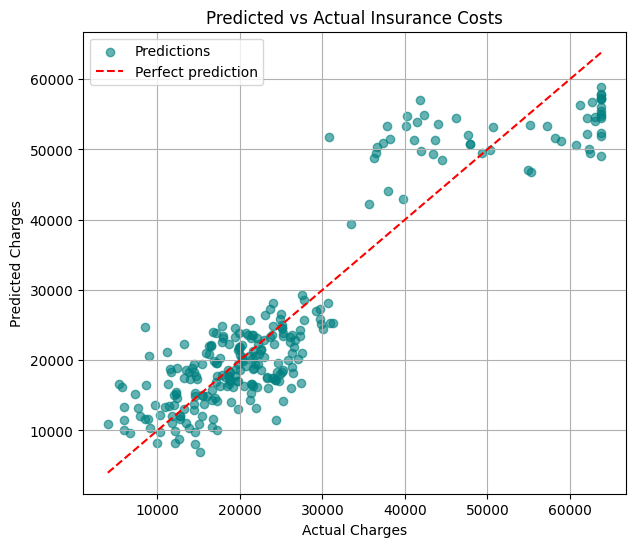

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal", label="Predictions")

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())
plt.plot([low, high], [low, high], "r--", label="Perfect prediction")

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Predicted vs Actual Insurance Costs")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation
- `smoker` is by far the strongest feature: smokers are charged much more.
- `age` and `bmi` also push the cost up; the `region` columns have only a small effect.
- The points spread around the line because a straight-line model cannot capture the interaction "smoker **and** high BMI", so some very expensive cases are under-predicted. Adding interaction or polynomial features could improve it.